# Notebook 3: Feature Engineering

## Purpose

In notebook 2 I cleaned the raw transaction data and produced `cleaned_data.csv`. This notebook takes that cleaned dataset and engineers the features that the ML models in notebooks 06a–06g will actually train on.

The key design decision here is that I work at **two levels of granularity**:

1. **Customer-level features** — I aggregate all transactions per customer into a single row describing that customer's overall behaviour. This is the input for churn prediction, customer segmentation, and CLV prediction — all of which model "what kind of customer is this person?"

2. **Transaction-level features** — I merge the customer-level aggregates back onto each individual transaction row. This is the input for fraud detection, recommendation systems, and demand forecasting — which model "what is the context of this specific transaction?"

I build the customer-level features across five groups: RFM (recency, frequency, monetary), temporal behaviour, product engagement, behavioural preferences, and demographics. I then combine all five groups into a single customer feature matrix, document every feature, and finally enrich the transaction-level dataset.

A `feature_log` dictionary tracks every feature created, in every group, so the engineering process is fully auditable.

**Steps in this notebook:**
1. Import libraries and load cleaned data
2. Set the reference date and initialise the feature log
3. Create RFM features
4. Create temporal behaviour features
5. Create product engagement features
6. Create behavioural preference features
7. Create demographic features
8. Combine all features into a single customer feature matrix
9. Document all features
10. Initial feature correlation analysis
11. Create transaction-level enriched dataset

## Step 1: Import Libraries and Load Data

I import `scipy.stats.entropy` here specifically for the product category diversity feature — Shannon entropy measures how spread out a customer's purchases are across categories. A customer who buys equally across electronics, clothing, and home goods has higher entropy than a customer who only ever buys electronics.

I also set a `REFERENCE_DATE` equal to the most recent transaction date in the dataset and initialise a `feature_log` dictionary. The reference date is used to calculate `Recency_Days` — how many days have passed since a customer's last purchase. I use the dataset's own most-recent date rather than today's date so the features are stable and reproducible: re-running the notebook produces the same values regardless of when it is run.

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from pathlib import Path
from scipy.stats import entropy  # used to compute category diversity (Shannon entropy) per customer
import json
import warnings
warnings.filterwarnings('ignore')

In [2]:
# parse_dates ensures Date and Transaction_DateTime are read as datetime64, not strings
df = pd.read_csv('../data/cleaned_data.csv', parse_dates=['Date', 'Transaction_DateTime'])
print(f"Loaded {len(df)} transactions")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Unique customers: {df['Customer_ID'].nunique()}")

Loaded 301006 transactions
Date range: 2023-03-01 00:00:00 to 2024-02-29 00:00:00
Unique customers: 86740


In [3]:
# Use the dataset's own max date as reference — makes Recency_Days stable regardless of when the notebook is run
REFERENCE_DATE = df['Date'].max()
print(f"Reference Date for Recency: {REFERENCE_DATE}")

# Initialise feature log — every feature group will append its feature names here
feature_log = {
    'created_at': datetime.now().isoformat(),
    'reference_date': str(REFERENCE_DATE),
    'n_transactions': len(df),
    'n_customers': df['Customer_ID'].nunique(),
    'features': {}  # populated incrementally as each group is built
}

Reference Date for Recency: 2024-02-29 00:00:00


## Step 2: Create RFM Features

RFM — Recency, Frequency, Monetary — is the most established framework for describing customer purchase behaviour. I compute it here as the foundation for the customer feature matrix. Every other feature group in this notebook extends or contextualises the RFM picture.

I start by aggregating all transactions per customer to get raw counts and totals, then derive the three core RFM metrics:

- **Recency**: Days since the customer's last purchase (measured from `REFERENCE_DATE`). Lower = more recently active.
- **Frequency**: Number of transactions normalised by time (`Transactions_Per_Month`). This accounts for customers with identical transaction counts but very different tenures.
- **Monetary**: Total lifetime spend (`Customer_LTV`) and average order value. I also compute the coefficient of variation (`Order_Value_CV`) to measure spend consistency — a customer who always spends ~£50 is different to one who alternates between £10 and £90.

Finally I convert the raw values to 1–5 quintile scores and sum them into a single `RFM_Score`. I use scores rather than raw values so that the three dimensions are on comparable scales when I combine them.

In [4]:
# Aggregate all transactions per customer — this collapses ~N rows per customer into one summary row
rfm_features = df.groupby('Customer_ID').agg({
    'Date': ['min', 'max', 'count'],           # first purchase, last purchase, total transaction count
    'Total_Amount': ['sum', 'mean', 'std'],    # total spend, average order, spend variability
    'Transaction_ID': 'count'                  # another way to count transactions (double-check)
}).reset_index()

# Flatten the multi-level column names into readable single-level names
rfm_features.columns = ['Customer_ID', 'First_Purchase_Date', 'Last_Purchase_Date',
                        'Transaction_Count', 'Total_Spend', 'Avg_Order_Value',
                        'Std_Order_Value', 'Frequency']

In [5]:
# Recency: days since last purchase — lower = more recently active
rfm_features['Recency_Days'] = (REFERENCE_DATE - rfm_features['Last_Purchase_Date']).dt.days

# Customer tenure: total days from first to last purchase
rfm_features['Customer_Tenure_Days'] = (
    rfm_features['Last_Purchase_Date'] - rfm_features['First_Purchase_Date']
).dt.days + 1  # +1 to avoid division by zero for single-transaction customers

# Transactions per month: normalise frequency by tenure so a 2-year customer with 10 orders
# is not treated as less active than a new customer with the same count
rfm_features['Transactions_Per_Month'] = (
    rfm_features['Transaction_Count'] / (rfm_features['Customer_Tenure_Days'] / 30)
).round(2)

# Monetary: total lifetime value
rfm_features['Customer_LTV'] = rfm_features['Total_Spend']

# Average gap between purchases — high values indicate infrequent, seasonal shoppers
rfm_features['Avg_Days_Between_Purchases'] = (
    rfm_features['Customer_Tenure_Days'] / rfm_features['Transaction_Count']
).round(2)

In [6]:
# Coefficient of variation: std / mean — measures spend consistency
# High CV means the customer's order sizes vary a lot; low CV means consistent basket sizes
rfm_features['Order_Value_CV'] = (
    rfm_features['Std_Order_Value'] / rfm_features['Avg_Order_Value']
).fillna(0)  # fillna(0) for customers with only one transaction (std = NaN)

# RFM Scores: convert raw values to 1–5 quintile labels so all three dimensions are comparable
# Recency is inverted (lower days = better = score 5) to match the standard RFM convention
rfm_features['Recency_Score'] = pd.qcut(
    rfm_features['Recency_Days'], q=5, labels=[5, 4, 3, 2, 1], duplicates='drop'
).astype(float)

# rank(method='first') breaks ties before qcut — prevents errors when many customers share the same count
rfm_features['Frequency_Score'] = pd.qcut(
    rfm_features['Transaction_Count'].rank(method='first'),
    q=5, labels=[1, 2, 3, 4, 5], duplicates='drop'
).astype(float)

rfm_features['Monetary_Score'] = pd.qcut(
    rfm_features['Total_Spend'], q=5, labels=[1, 2, 3, 4, 5], duplicates='drop'
).astype(float)

In [7]:
# Combined RFM Score
rfm_features['RFM_Score'] = (
    rfm_features['Recency_Score'] + 
    rfm_features['Frequency_Score'] + 
    rfm_features['Monetary_Score']
)

print(f"RFM features created: {rfm_features.shape[1] - 1} features")

# Log features
feature_log['features']['rfm'] = [
    'Recency_Days', 'Transaction_Count', 'Transactions_Per_Month', 
    'Customer_LTV', 'Avg_Order_Value', 'Std_Order_Value', 'Order_Value_CV',
    'Customer_Tenure_Days', 'Avg_Days_Between_Purchases',
    'Recency_Score', 'Frequency_Score', 'Monetary_Score', 'RFM_Score'
]

RFM features created: 17 features


## Step 3: Create Temporal Behaviour Features

RFM treats a customer's whole history as a static snapshot. Temporal features capture whether customer behaviour is changing. The most important feature here is the **purchase velocity ratio**: the ratio of transactions in the last 30 days to the historical average. A ratio above 1 means the customer is accelerating; below 1 means they are slowing down. This is a strong early signal for both churn (slowing customers) and upsell opportunities (accelerating customers).

I also extract time-of-day and day-of-week preferences by computing the modal shopping hour and day per customer. These are useful for the recommendation system — a customer who predominantly shops on Saturday evenings is likely in a different mindset than a weekday lunchtime shopper.

In [8]:
# Split transactions into "recent" (last 30 days) vs "historical" (everything before)
# This allows computing velocity ratios: how does recent activity compare to the customer's baseline?
cutoff_date = REFERENCE_DATE - timedelta(days=30)

recent_txns = df[df['Date'] > cutoff_date].groupby('Customer_ID').agg({
    'Transaction_ID': 'count',
    'Total_Amount': 'sum'
}).rename(columns={'Transaction_ID': 'Recent_Txn_Count', 'Total_Amount': 'Recent_Spend'})

historical_txns = df[df['Date'] <= cutoff_date].groupby('Customer_ID').agg({
    'Transaction_ID': 'count',
    'Total_Amount': 'sum'
}).rename(columns={'Transaction_ID': 'Historical_Txn_Count', 'Total_Amount': 'Historical_Spend'})

temporal_features = rfm_features[['Customer_ID']].merge(recent_txns, on='Customer_ID', how='left')
temporal_features = temporal_features.merge(historical_txns, on='Customer_ID', how='left')

In [9]:
temporal_features.fillna(0, inplace=True)  # customers with no recent activity get 0, not NaN

# Purchase velocity ratio: recent transactions / historical transactions
# > 1.0 = customer is buying more than their historical rate (acceleration)
# < 1.0 = customer is buying less than their historical rate (deceleration — churn risk)
temporal_features['Purchase_Velocity_Ratio'] = np.where(
    temporal_features['Historical_Txn_Count'] > 0,
    temporal_features['Recent_Txn_Count'] / temporal_features['Historical_Txn_Count'],
    0  # customers with no history default to 0 rather than inf
)

# Same ratio for spend — a customer may be buying at the same frequency but spending less
temporal_features['Spending_Velocity_Ratio'] = np.where(
    temporal_features['Historical_Spend'] > 0,
    temporal_features['Recent_Spend'] / temporal_features['Historical_Spend'],
    0
)

In [10]:
# Time-based preferences
time_prefs = df.groupby('Customer_ID').agg({
    'Hour': lambda x: x.mode()[0] if len(x.mode()) > 0 else x.mean(),
    'IsWeekend': 'mean',
    'DayOfWeek': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Unknown'
}).rename(columns={
    'Hour': 'Preferred_Hour',
    'IsWeekend': 'Weekend_Purchase_Pct',
    'DayOfWeek': 'Preferred_Day'
})

temporal_features = temporal_features.merge(time_prefs, on='Customer_ID', how='left')

In [11]:
# Day of week encoding (0=Monday, 6=Sunday)
day_mapping = {
    'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3,
    'Friday': 4, 'Saturday': 5, 'Sunday': 6, 'Unknown': -1
}
temporal_features['Preferred_Day_Encoded'] = temporal_features['Preferred_Day'].map(day_mapping)

print(f"Temporal features created: {temporal_features.shape[1] - 1} features")

feature_log['features']['temporal'] = [
    'Recent_Txn_Count', 'Recent_Spend', 'Historical_Txn_Count', 'Historical_Spend',
    'Purchase_Velocity_Ratio', 'Spending_Velocity_Ratio', 'Preferred_Hour',
    'Weekend_Purchase_Pct', 'Preferred_Day_Encoded'
]

Temporal features created: 10 features


## Step 4: Create Product Engagement Features

These features describe how a customer explores the product catalogue and how satisfied they appear to be. The key feature here is **Category Entropy**, computed using Shannon entropy from `scipy.stats.entropy`. Entropy measures the spread of purchases across categories — a customer who buys exclusively electronics has entropy 0, while a customer who buys equally across all categories has maximum entropy. High-entropy customers are more exploratory and tend to respond better to cross-category recommendations.

I also compute `Is_Satisfied_Customer` as a binary flag for whether a customer's average rating is 4.0 or higher. This is intentionally a simple threshold — it feeds directly into the sentiment and recommendation models as a pre-computed label rather than calculating it at model time.

In [12]:
# Product category diversity
category_stats = df.groupby('Customer_ID')['Product_Category'].agg([
    ('Unique_Categories', 'nunique'),
    ('Favorite_Category', lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Unknown'),
    ('Category_List', lambda x: list(x))
])

In [13]:
def calculate_entropy(categories):
    """
    Computes Shannon entropy for a list of category labels.
    Returns 0 for a customer who only ever buys from one category.
    Returns higher values for customers who buy evenly across many categories.
    This is used as a feature in both the recommendation and segmentation models.
    """
    value_counts = pd.Series(categories).value_counts()
    probabilities = value_counts / len(categories)  # convert counts to probabilities
    return entropy(probabilities)  # scipy.stats.entropy computes -sum(p * log(p))

category_stats['Category_Entropy'] = category_stats['Category_List'].apply(calculate_entropy)
category_stats.drop('Category_List', axis=1, inplace=True)  # drop the raw list — we only needed it for entropy

# Brand diversity: number of distinct brands a customer has purchased from
brand_stats = df.groupby('Customer_ID')['Product_Brand'].agg([
    ('Unique_Brands', 'nunique')
])

In [14]:
# Rating behavior
rating_stats = df.groupby('Customer_ID')['Ratings'].agg([
    ('Avg_Rating', 'mean'),
    ('Std_Rating', 'std'),
    ('Min_Rating', 'min'),
    ('Max_Rating', 'max')
]).fillna(0)

# Combine product features
product_features = category_stats.merge(brand_stats, on='Customer_ID', how='left')
product_features = product_features.merge(rating_stats, on='Customer_ID', how='left')
product_features.reset_index(inplace=True)

# Is customer satisfied (avg rating >= 4)
product_features['Is_Satisfied_Customer'] = (product_features['Avg_Rating'] >= 4).astype(int)

print(f"Product engagement features created: {product_features.shape[1] - 1} features")

Product engagement features created: 9 features


In [15]:
# Is customer satisfied (avg rating >= 4)
product_features['Is_Satisfied_Customer'] = (product_features['Avg_Rating'] >= 4).astype(int)

print(f"Product engagement features created: {product_features.shape[1] - 1} features")
feature_log['features']['product_engagement'] = [
    'Unique_Categories', 'Category_Entropy', 'Unique_Brands',
    'Avg_Rating', 'Std_Rating', 'Min_Rating', 'Max_Rating', 'Is_Satisfied_Customer'
]

Product engagement features created: 9 features


## Step 5: Create Behavioural Preference Features

These features capture the operational side of a customer's purchasing behaviour — how they pay, how they ship, and what the status of their orders tends to be.

`Payment_Method_Changes` counts how many distinct payment methods a customer has used. A high value can indicate either flexibility or experimentation with new accounts — the fraud detection model uses this as one signal among several.

`Pct_Cancelled` is the fraction of a customer's orders that were cancelled. Customers with consistently high cancellation rates behave very differently from those with mostly completed orders, and this difference matters to both the CLV model and the recommendation system.

Average and standard deviation of cart size (`Avg_Cart_Size`, `Std_Cart_Size`) describe how consistently sized the customer's baskets are. High `Std_Cart_Size` can indicate occasional bulk purchases alongside regular small purchases — potentially relevant to demand forecasting.

In [16]:
# Payment and shipping preferences
payment_prefs = df.groupby('Customer_ID')['Payment_Method'].agg([
    ('Preferred_Payment', lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Unknown'),
    ('Payment_Method_Changes', 'nunique')
])

shipping_prefs = df.groupby('Customer_ID')['Shipping_Method'].agg([
    ('Preferred_Shipping', lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Unknown'),
    ('Shipping_Method_Changes', 'nunique')
])

In [17]:
# Order status distribution
order_stats = df.groupby('Customer_ID')['Order_Status'].agg([
    ('Pct_Shipped', lambda x: (x == 'Shipped').sum() / len(x)),
    ('Pct_Processing', lambda x: (x == 'Processing').sum() / len(x)),
    ('Pct_Cancelled', lambda x: (x == 'Cancelled').sum() / len(x) if 'Cancelled' in x.values else 0)
])

# Total purchases per transaction (cart size indicator)
cart_size = df.groupby('Customer_ID')['Total_Purchases'].agg([
    ('Avg_Cart_Size', lambda x: pd.to_numeric(x, errors='coerce').mean()),
    ('Max_Cart_Size', lambda x: pd.to_numeric(x, errors='coerce').max()),
    ('Std_Cart_Size', lambda x: pd.to_numeric(x, errors='coerce').std())
]).fillna(0)

In [18]:
# Combine behavioral features
behavioral_features = payment_prefs.merge(shipping_prefs, on='Customer_ID', how='left')
behavioral_features = behavioral_features.merge(order_stats, on='Customer_ID', how='left')
behavioral_features = behavioral_features.merge(cart_size, on='Customer_ID', how='left')
behavioral_features.reset_index(inplace=True)

print(f"Behavioral features created: {behavioral_features.shape[1] - 1} features")

feature_log['features']['behavioral'] = [
    'Payment_Method_Changes', 'Shipping_Method_Changes',
    'Pct_Shipped', 'Pct_Processing', 'Pct_Cancelled',
    'Avg_Cart_Size', 'Max_Cart_Size', 'Std_Cart_Size'
]

Behavioral features created: 10 features


## Step 6: Create Demographic Features

Demographic features describe who the customer is rather than how they behave. I use `groupby('Customer_ID').agg('first')` to extract these — since these are customer-level attributes that do not change between transactions, I just take the first observed value per customer.

I create `Age_Group` by bucketing continuous `Age` into common retail age segments (18–24, 25–34, etc.). The bucketed version is more useful than raw age in models like the segmentation clustering, where extreme age values can distort distance calculations. The original `Age` column is kept alongside the group for models that benefit from continuous input.

In [19]:
# Demographic attributes are constant per customer — .agg('first') takes the first observed value
# This is the correct approach for columns like Age, Gender, Income that should not vary across rows
demographic_features = df.groupby('Customer_ID').agg({
    'Age': 'first',
    'Gender': 'first',
    'Income': 'first',
    'City': 'first',
    'State': 'first',
    'Country': 'first',
    'Customer_Segment': 'first'
}).reset_index()

def categorize_age(age):
    """
    Converts a continuous age value to a standard retail age bracket.
    The bucketed version is useful in clustering where raw age can distort distances.
    I keep both the raw Age and the Age_Group so models can choose which to use.
    """
    if pd.isna(age):
        return 'Unknown'
    elif age < 25:
        return '18-24'
    elif age < 35:
        return '25-34'
    elif age < 45:
        return '35-44'
    elif age < 55:
        return '45-54'
    elif age < 65:
        return '55-64'
    else:
        return '65+'

demographic_features['Age_Group'] = demographic_features['Age'].apply(categorize_age)

In [20]:
print(f"Demographic features created: {demographic_features.shape[1] - 1} features")

feature_log['features']['demographic'] = [
    'Age', 'Gender', 'Income', 'State', 'Customer_Segment',
    'Age_Group', 'Income_Bracket'
]

Demographic features created: 8 features


## Step 7: Combine All Customer Features

I merge all five feature groups on `Customer_ID` using left joins starting from the RFM base. Left join is deliberate — if a customer appears in the RFM features but has no product engagement data (e.g., all their categories were null and got dropped), I still want a row for that customer, just with zeros for the missing group. Using an inner join would silently drop customers with incomplete data from any group.

After all merges, `customer_features.fillna(0)` fills any remaining NaN from the left joins. This is safe here because all feature groups are aggregates — a zero means the customer had no observed activity in that dimension, which is the correct interpretation.

In [21]:
# Start with RFM features
customer_features = rfm_features.copy()

# Merge temporal features
customer_features = customer_features.merge(
    temporal_features[['Customer_ID'] + [col for col in temporal_features.columns if col != 'Customer_ID']],
    on='Customer_ID',
    how='left'
)

# Merge product features
customer_features = customer_features.merge(
    product_features,
    on='Customer_ID',
    how='left'
)

# Merge behavioral features
customer_features = customer_features.merge(
    behavioral_features,
    on='Customer_ID',
    how='left'
)

# Merge demographic features
customer_features = customer_features.merge(
    demographic_features,
    on='Customer_ID',
    how='left'
)

# Handle any remaining missing values
customer_features.fillna(0, inplace=True)

print(f"\nFinal feature matrix shape: {customer_features.shape}")
print(f"Total customers: {len(customer_features)}")
print(f"Total features: {customer_features.shape[1] - 1}")

# Feature summary
print("\nFeature Summary by Category:")
for category, features in feature_log['features'].items():
    print(f"  {category}: {len(features)} features")


Final feature matrix shape: (86740, 55)
Total customers: 86740
Total features: 54

Feature Summary by Category:
  rfm: 13 features
  temporal: 9 features
  product_engagement: 8 features
  behavioral: 8 features
  demographic: 7 features


## Step 8: Document Features and Save Customer-Level Dataset

I create a `feature_descriptions.csv` reference table that maps every feature name to its category, data type, description, and business meaning. This serves as the technical reference when someone asked "what is `Order_Value_CV`?" — the answer is in the CSV rather than requiring them to read through the notebook code.

I save two files in this step:
1. `customer_features_enriched.csv` — the complete customer feature matrix used by the churn, segmentation, and CLV models
2. `feature_descriptions.csv` — the feature dictionary for documentation

The `feature_log` is also serialised to `feature_engineering_log.json` so there is a machine-readable record of exactly which features were created.

In [22]:

# Create feature description dataframe
feature_descriptions = {
    'Feature_Name': [],
    'Category': [],
    'Data_Type': [],
    'Description': [],
    'Business_Meaning': []
}

# Define descriptions (sample - expand for all features)
descriptions_map = {
    'Recency_Days': {
        'category': 'RFM',
        'description': 'Days since last purchase',
        'meaning': 'Lower values indicate recent activity, key churn predictor'
    },
    'Transaction_Count': {
        'category': 'RFM',
        'description': 'Total number of transactions',
        'meaning': 'Higher values indicate loyal, engaged customers'
    },
    'Customer_LTV': {
        'category': 'RFM',
        'description': 'Total amount spent across all purchases',
        'meaning': 'Represents total customer value'
    },
    'Purchase_Velocity_Ratio': {
        'category': 'Temporal',
        'description': 'Recent purchase rate / Historical purchase rate',
        'meaning': 'Values >1 indicate increasing engagement, <1 decreasing'
    },
    'Category_Entropy': {
        'category': 'Product',
        'description': 'Shannon entropy of product category purchases',
        'meaning': 'Higher values indicate diverse shopping behavior'
    },
    'Is_Satisfied_Customer': {
        'category': 'Product',
        'description': 'Binary flag for average rating >= 4.0',
        'meaning': 'Indicates customer satisfaction level'
    }
    # Add more descriptions as needed
}

# Populate feature descriptions
for col in customer_features.columns:
    if col == 'Customer_ID':
        continue
    
    desc = descriptions_map.get(col, {
        'category': 'Other',
        'description': f'Auto-generated feature: {col}',
        'meaning': 'See feature engineering documentation'
    })
    
    feature_descriptions['Feature_Name'].append(col)
    feature_descriptions['Category'].append(desc.get('category', 'Other'))
    feature_descriptions['Data_Type'].append(str(customer_features[col].dtype))
    feature_descriptions['Description'].append(desc.get('description', ''))
    feature_descriptions['Business_Meaning'].append(desc.get('meaning', ''))

feature_desc_df = pd.DataFrame(feature_descriptions)
feature_desc_df.to_csv('../data/feature_descriptions.csv', index=False)
print("Feature descriptions saved")

Feature descriptions saved


In [23]:
# Save the customer-level feature matrix — input for churn, segmentation, CLV models
output_path = '../data/customer_features.csv'
customer_features.to_csv(output_path, index=False)
print(f"Customer features saved to: {output_path}")

# Update feature log with final statistics
feature_log['final_stats'] = {
    'n_customers': len(customer_features),
    'n_features': customer_features.shape[1] - 1,
    'numerical_features': customer_features.select_dtypes(include=[np.number]).shape[1],
    'categorical_features': customer_features.select_dtypes(include=['object']).shape[1]
}

# Serialise the feature log for downstream reference
with open('../data/feature_engineering_log.json', 'w') as f:
    json.dump(feature_log, f, indent=2)

print("\nSample of engineered features:")
print(customer_features.head())

Customer features saved to: ../data/customer_features.csv

Sample of engineered features:
   Customer_ID First_Purchase_Date Last_Purchase_Date  Transaction_Count  \
0        10000          2023-05-15         2023-11-19                  4   
1        10001          2023-03-15         2023-11-17                  5   
2        10002          2023-04-20         2023-11-27                  5   
3        10003          2023-05-02         2023-07-17                  2   
4        10004          2023-10-07         2024-01-30                  2   

   Total_Spend  Avg_Order_Value  Std_Order_Value  Frequency  Recency_Days  \
0  5007.566357      1251.891589      1082.822084          4           102   
1  8136.462824      1627.292565      1348.648304          5           104   
2  4104.013951       820.802790      1131.996776          5            94   
3  2340.496447      1170.248223      1018.923407          2           227   
4  2356.516683      1178.258341       513.160623          2         

## Step 9: Initial Feature Correlation Analysis

Before saving and moving on, I run a quick sanity check on the features by plotting the top 10 features most correlated with each of the four key metrics: `Recency_Days`, `Transaction_Count`, `Customer_LTV`, and `RFM_Score`.

This serves two purposes: it confirms the features make intuitive sense (for example, `Transactions_Per_Month` should correlate strongly with `Transaction_Count`), and it gives me a preview of which features will likely matter most in the downstream models. Features that show no correlation with any key metric may be candidates for removal during the model feature selection step in notebook 06a onwards.

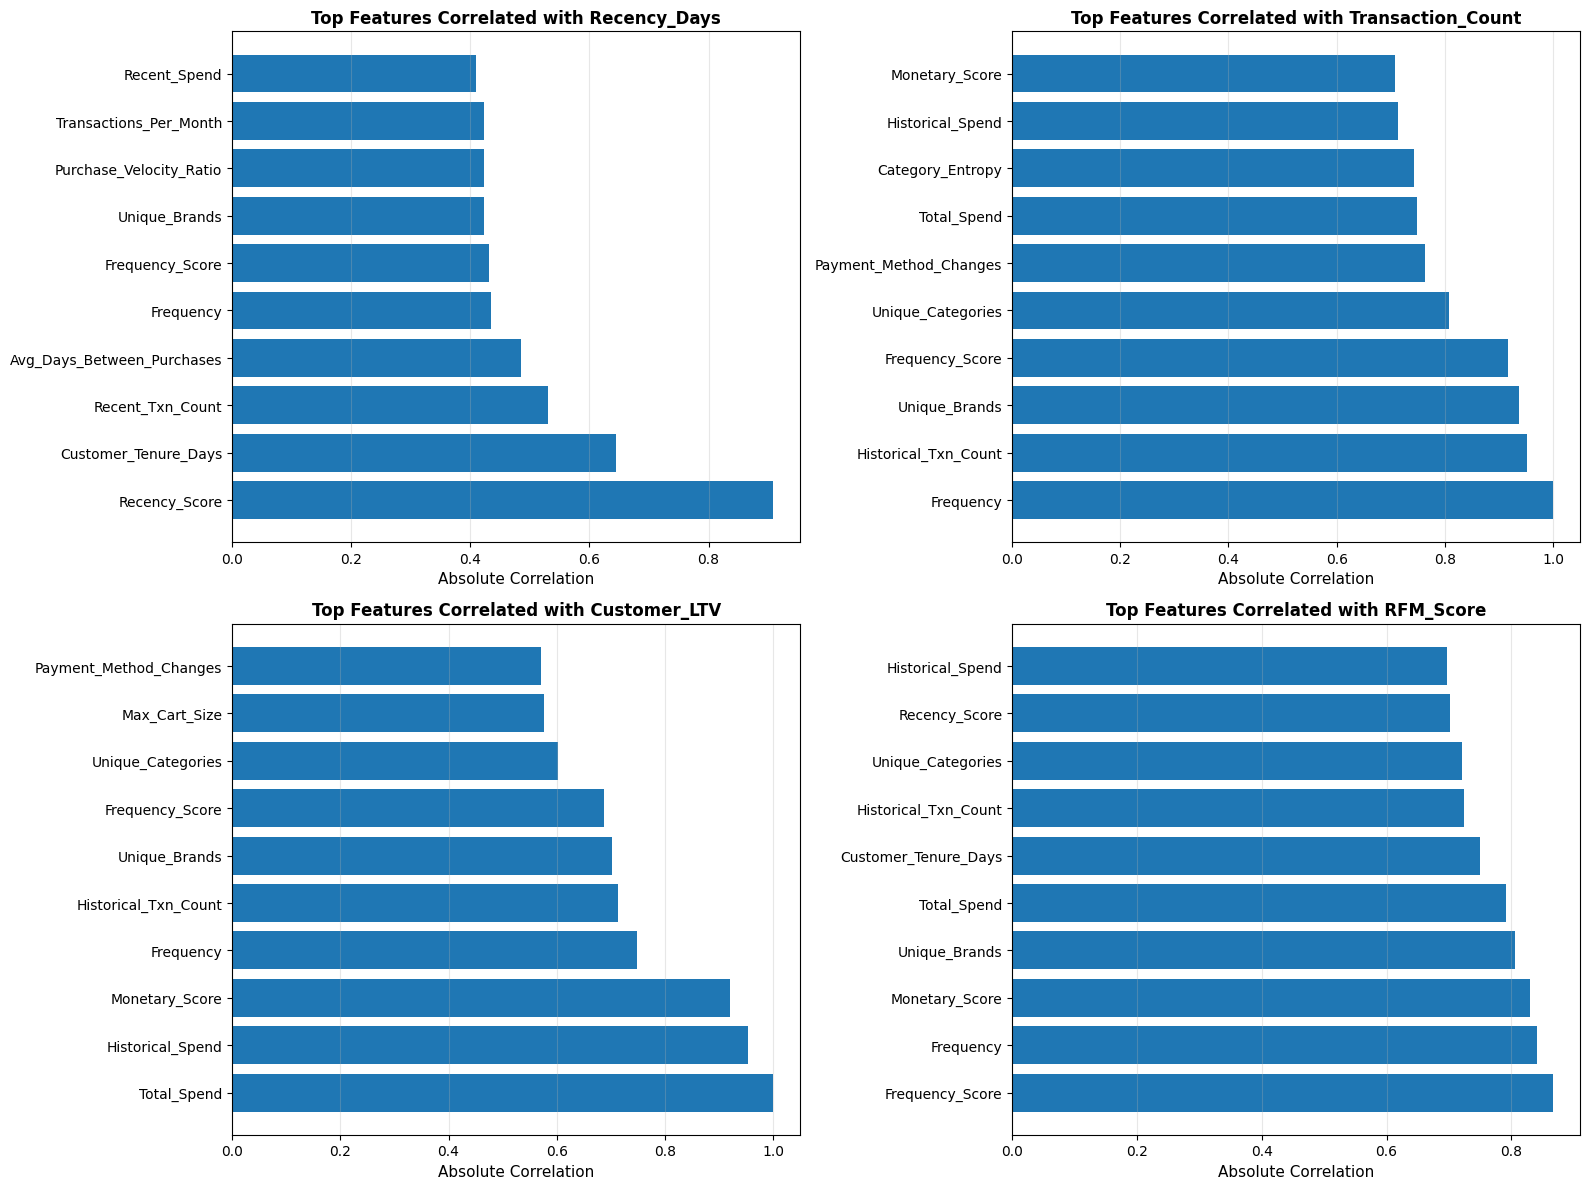

In [24]:
# Select numerical features for correlation analysis — exclude Customer_ID
numerical_cols = customer_features.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols.remove('Customer_ID')

# Compute correlations between all numerical features and the four key RFM metrics
key_metrics = ['Recency_Days', 'Transaction_Count', 'Customer_LTV', 'RFM_Score']
correlation_df = customer_features[numerical_cols].corr()[key_metrics].drop(key_metrics)

# Plot the top 10 features most correlated with each key metric
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for idx, metric in enumerate(key_metrics):
    row = idx // 2
    col = idx % 2

    top_corr = correlation_df[metric].abs().nlargest(10)

    axes[row, col].barh(range(len(top_corr)), top_corr.values)
    axes[row, col].set_yticks(range(len(top_corr)))
    axes[row, col].set_yticklabels(top_corr.index, fontsize=10)
    axes[row, col].set_xlabel('Absolute Correlation', fontsize=11)
    axes[row, col].set_title(f'Top Features Correlated with {metric}', fontsize=12, fontweight='bold')
    axes[row, col].grid(True, alpha=0.3, axis='x')

plt.tight_layout()

In [25]:
plt.savefig('../reports/feature_importance_analysis.png', dpi=300, bbox_inches='tight')
plt.close()

In [26]:
# Persist final engineered dataset snapshot
feature_data_dir = Path('../data')
feature_data_dir.mkdir(parents=True, exist_ok=True)

final_feature_path = feature_data_dir / 'customer_features_enriched.csv'
customer_features.to_csv(final_feature_path, index=False)

print('Final customer-level engineered dataset saved to:', final_feature_path)

Final customer-level engineered dataset saved to: ..\data\customer_features_enriched.csv


## Step 10: Create Transaction-Level Enriched Dataset

The customer-level features I just built describe each customer as a single summary row. But several of the downstream models — fraud detection, recommendation systems, demand forecasting, and sentiment analysis — operate on individual transactions, not on customer summaries.

In this step I merge the customer-level feature matrix back onto every row of the transaction data. Each transaction now carries full context: not just the raw transaction details, but also the customer's historical RFM profile, their behavioural tendencies, and their demographic segment.

I then add transaction-specific features that can only be computed at the transaction level — things like "is this transaction in the customer's favourite category?" or "is this purchase amount unusually high relative to the customer's average?" These are the features that make fraud detection and recommendation models effective, because they capture deviation from established patterns.

In [27]:
print(f"Original transaction data: {len(df)} rows")

# Load the enriched customer features (saved above) to merge onto each transaction
customer_features = pd.read_csv('../data/customer_features_enriched.csv')
print(f"Customer features: {len(customer_features)} customers")

# Start with the full cleaned transaction dataset — every row will be retained
transaction_enriched = df.copy()

customer_features_for_merge = customer_features.copy()

# Convert date columns to string before merge to avoid dtype conflicts
date_cols = ['First_Purchase_Date', 'Last_Purchase_Date']
for col in date_cols:
    if col in customer_features_for_merge.columns:
        customer_features_for_merge[col] = customer_features_for_merge[col].astype(str)

# Left join so every original transaction row is preserved
# suffixes=('', '_customer_agg') avoids column name clashes where both tables share column names
transaction_enriched = transaction_enriched.merge(
    customer_features_for_merge,
    on='Customer_ID',
    how='left',
    suffixes=('', '_customer_agg')
)

print(f"Transaction-level enriched shape: {transaction_enriched.shape}")
print(f"Rows retained: {len(transaction_enriched)} (should match original {len(df)})")

Original transaction data: 301006 rows
Customer features: 86740 customers
Transaction-level enriched shape: (301006, 93)
Rows retained: 301006 (should match original 301006)


In [28]:
# Add transaction-specific features useful for fraud detection and recommendations

# 1. Transaction recency (days from customer's last purchase)
transaction_enriched['Days_Since_Customer_Last_Purchase'] = (
    REFERENCE_DATE - pd.to_datetime(transaction_enriched['Date'])
).dt.days

# 2. Is this in customer's favorite category?
transaction_enriched['Is_Favorite_Category'] = (
    transaction_enriched['Product_Category'] == transaction_enriched['Favorite_Category']
).astype(int)

# 3. Is this customer's preferred payment method?
transaction_enriched['Is_Preferred_Payment'] = (
    transaction_enriched['Payment_Method'] == transaction_enriched['Preferred_Payment']
).astype(int)

# 4. Is this customer's preferred shipping method?
transaction_enriched['Is_Preferred_Shipping'] = (
    transaction_enriched['Shipping_Method'] == transaction_enriched['Preferred_Shipping']
).astype(int)

# 5. Transaction amount vs customer average (anomaly indicator)
transaction_enriched['Amount_vs_Avg_Ratio'] = (
    transaction_enriched['Total_Amount'] / transaction_enriched['Avg_Order_Value']
).fillna(1)

# 6. Is high-value transaction (fraud indicator)
transaction_enriched['Is_High_Value_Txn'] = (
    transaction_enriched['Total_Amount'] > transaction_enriched['Total_Amount'].quantile(0.95)
).astype(int)

# 7. Cart size vs customer average (fraud indicator) - handle non-numeric values
transaction_enriched['Total_Purchases_numeric'] = pd.to_numeric(
    transaction_enriched['Total_Purchases'], errors='coerce'
).fillna(1)  # Fill missing with 1

transaction_enriched['Cart_Size_vs_Avg_Ratio'] = transaction_enriched['Total_Purchases_numeric'] / (
    transaction_enriched['Avg_Cart_Size'] + 0.001  # avoid division by zero
)

# 8. Purchase at unusual hour for customer
transaction_enriched['Is_Unusual_Hour'] = (
    abs(transaction_enriched['Hour'] - transaction_enriched['Preferred_Hour']) > 6
).astype(int)

# 9. Weekend preference match
transaction_enriched['Weekend_Preference_Match'] = (
    (transaction_enriched['IsWeekend'] == 1) & 
    (transaction_enriched['Weekend_Purchase_Pct'] > 0.5)
).astype(int)

# 10. Customer satisfaction flag (for sentiment/rating models)
transaction_enriched['Customer_Satisfaction_Flag'] = transaction_enriched['Is_Satisfied_Customer']

print(f"\nTransaction-specific features added: 10+ features")
print(f"Final transaction-level enriched shape: {transaction_enriched.shape}")


Transaction-specific features added: 10+ features
Final transaction-level enriched shape: (301006, 104)


In [29]:
# Additional features specifically for FRAUD DETECTION

# 1. Time since first purchase - very new customers are higher fraud risk
transaction_enriched['Transaction_Days_Since_First_Purchase'] = transaction_enriched['DaysSinceFirstPurchase']

# 2. First transaction flag (fraud risk indicator)
transaction_enriched['Is_First_Transaction'] = (
    transaction_enriched['Transaction_Days_Since_First_Purchase'] == 0
).astype(int)

# 3. Velocity anomaly - sudden spike in activity
transaction_enriched['Is_Velocity_Spike'] = (
    transaction_enriched['Purchase_Velocity_Ratio'] > 2.0
).astype(int)

# 4. Low rating on high-value purchase (fraud/dispute indicator)
transaction_enriched['Low_Rating_High_Value'] = (
    (transaction_enriched['Ratings'] <= 2) & 
    (transaction_enriched['Is_High_Value_Txn'] == 1)
).astype(int)

# 5. Multiple categories (fraud pattern)
transaction_enriched['High_Category_Diversity'] = (
    transaction_enriched['Unique_Categories'] > 5
).astype(int)

# 6. Processing/Cancelled status flag
transaction_enriched['Is_Problem_Order'] = (
    transaction_enriched['Order_Status'].isin(['Processing', 'Cancelled'])
).astype(int)

print(f"Fraud detection features added: 6 features")

Fraud detection features added: 6 features


In [30]:
# Additional features for RECOMMENDATION SYSTEMS

# 1. Product brand consistency score
transaction_enriched['Brand_Diversity_Score'] = transaction_enriched['Unique_Brands']

# 2. Category exploration score (entropy)
transaction_enriched['Category_Exploration_Score'] = transaction_enriched['Category_Entropy']

# 3. Rating consistency
transaction_enriched['Rating_Consistency_Score'] = (
    1 / (transaction_enriched['Std_Rating'] + 0.1)  # Higher = more consistent
)

# 4. Repeat buyer strength
transaction_enriched['Repeat_Buyer_Score'] = np.log1p(transaction_enriched['Transaction_Count'])

# 5. Engagement level (combination of recency, frequency, monetary)
transaction_enriched['Customer_Engagement_Score'] = transaction_enriched['RFM_Score']

print(f"Recommendation features added: 5 features")

Recommendation features added: 5 features


In [31]:
# Save the transaction-level enriched dataset — this is the input for fraud, recommendations, forecasting
transaction_enriched_path = feature_data_dir / 'transaction_level_enriched.csv'
transaction_enriched.to_csv(transaction_enriched_path, index=False)

print(f"Transaction-level enriched dataset saved to: {transaction_enriched_path}")
print(f"   Rows: {len(transaction_enriched):,}")
print(f"   Columns: {transaction_enriched.shape[1]}")
print(f"   Original rows preserved: {len(transaction_enriched) == len(df)}")

# Update feature log with transaction-level statistics
feature_log['transaction_level'] = {
    'n_transactions': len(transaction_enriched),
    'n_features': transaction_enriched.shape[1],
    'added_features': [
        'Is_Favorite_Category', 'Is_Preferred_Payment', 'Is_Preferred_Shipping',
        'Amount_vs_Avg_Ratio', 'Is_High_Value_Txn', 'Cart_Size_vs_Avg_Ratio',
        'Is_Unusual_Hour', 'Weekend_Preference_Match', 'Is_First_Transaction',
        'Is_Velocity_Spike', 'Low_Rating_High_Value', 'Is_Problem_Order',
        'Brand_Diversity_Score', 'Category_Exploration_Score', 'Rating_Consistency_Score',
        'Repeat_Buyer_Score', 'Customer_Engagement_Score'
    ]
}

# Re-save feature log with the updated transaction-level section
with open('../data/feature_engineering_log.json', 'w') as f:
    json.dump(feature_log, f, indent=2)

Transaction-level enriched dataset saved to: ..\data\transaction_level_enriched.csv
   Rows: 301,006
   Columns: 115
   Original rows preserved: True


In [32]:
# Summary of what was produced by this notebook
print("Customer-level dataset:")
print(f"   File:     customer_features_enriched.csv")
print(f"   Rows:     {len(customer_features):,} customers")
print(f"   Features: {customer_features.shape[1] - 1}")
print(f"   Used by:  churn prediction, customer segmentation, CLV prediction")

print("\nTransaction-level dataset:")
print(f"   File:     transaction_level_enriched.csv")
print(f"   Rows:     {len(transaction_enriched):,} transactions")
print(f"   Features: {transaction_enriched.shape[1]}")
print(f"   Used by:  recommendation systems, fraud detection, demand forecasting, sentiment analysis")

Customer-level dataset:
   File:     customer_features_enriched.csv
   Rows:     86,740 customers
   Features: 54
   Used by:  churn prediction, customer segmentation, CLV prediction

Transaction-level dataset:
   File:     transaction_level_enriched.csv
   Rows:     301,006 transactions
   Features: 115
   Used by:  recommendation systems, fraud detection, demand forecasting, sentiment analysis
